# Rhein-Neckar Labour Market Analysis

### Employment and Unemployment Trends in Five German Cities

This project analyzes labour market trends in **Ludwigshafen, Mannheim, Heidelberg, Speyer and Frankenthal** using official data from the German Federal Employment Agency (Bundesagentur für Arbeit).

The analysis focuses on three main questions:

1. How do employment rates differ between the five cities?
2. How have employment and unemployment developed between 2023 and 2025?
3. Are there recurring patterns in monthly unemployment rates?

The analysis was performed using **Python, Pandas, Matplotlib and Seaborn**.

## 1. Setup

## 1. Setup

Import the Python libraries used for data manipulation and visualization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

## 2. Data Loading

The analysis uses two official datasets from the German Federal Employment Agency:

- **Employment rates** at district level
- **Monthly unemployment rates** at district level

The analysis covers Ludwigshafen, Mannheim, Heidelberg, Speyer and Frankenthal.

In [20]:
employment_2023 = pd.read_excel(
    "../data/bq-heft-dlkaa-0-202506-xlsx.xlsx",
    sheet_name="Kreise 2023",
    header=[6, 7]
)

employment_2024 = pd.read_excel(
    "../data/bq-heft-dlkaa-0-202506-xlsx.xlsx",
    sheet_name="Kreise 2024",
    header=[6, 7]
)

employment_2025 = pd.read_excel(
    "../data/bq-heft-dlkaa-0-202506-xlsx.xlsx",
    sheet_name="Kreise 2025",
    header=[6, 7]
)

## 3. Data Cleaning

The raw datasets contain multi-level headers, metadata rows and official administrative city names.

The data is cleaned and standardized before the analysis.

### 3.1 Employment Data

In [21]:
def pulisci_dati(df):

    # Elimina la prima riga con i numeri 1, 2, 3...
    df = df.drop(0)
    df = df.reset_index(drop=True)

    # Appiattisce le colonne MultiIndex
    nuove_colonne = []

    for colonna in df.columns:
        nuove_colonne.append(colonna[0] + "_" + colonna[1])

    df.columns = nuove_colonne

    # Rinomina la colonna Region
    df = df.rename(
        columns={"Region_Unnamed: 0_level_1": "Region"}
    )

    # Pulisce i nomi delle colonne
    colonne_pulite = []

    for colonna in df.columns:

        for numero in ["1)", "2)", "3)"]:
            colonna = colonna.replace(numero, "")

        colonna = colonna.replace("  _", "_")
        colonna = colonna.replace(" _", "_")

        colonne_pulite.append(colonna)

    df.columns = colonne_pulite

    # Elimina le righe finali di note
    df = df[
        df["Bevölkerung_Insgesamt"].notnull()
    ]

    df = df.reset_index(drop=True)

    return df

In [22]:
employment_2023 = pulisci_dati(employment_2023)
employment_2024 = pulisci_dati(employment_2024)
employment_2025 = pulisci_dati(employment_2025)

The analysis focuses on five cities in the Rhein-Neckar region: Ludwigshafen, Mannheim, Heidelberg, Speyer and Frankenthal.

The official administrative city names are standardized to improve readability throughout the analysis.

In [24]:
citta = "Ludwigshafen|Mannheim|Heidelberg|Speyer|Frankenthal"

employment_2023 = employment_2023[
    employment_2023["Region"].str.contains(citta, na=False)
].reset_index(drop=True)

employment_2024 = employment_2024[
    employment_2024["Region"].str.contains(citta, na=False)
].reset_index(drop=True)

employment_2025 = employment_2025[
    employment_2025["Region"].str.contains(citta, na=False)
].reset_index(drop=True)

In [26]:
nomi_citta = {
    "07311 Frankenthal (Pfalz), kreisfreie Stadt": "Frankenthal",
    "07314 Ludwigshafen am Rhein, kreisfreie Stadt": "Ludwigshafen",
    "07318 Speyer, kreisfreie Stadt": "Speyer",
    "08221 Heidelberg, Stadt": "Heidelberg",
    "08222 Mannheim, Universitätsstadt": "Mannheim"
}

employment_2023["Region"] = employment_2023["Region"].replace(nomi_citta)
employment_2024["Region"] = employment_2024["Region"].replace(nomi_citta)
employment_2025["Region"] = employment_2025["Region"].replace(nomi_citta)

### 3.2 Unemployment Data

Monthly unemployment data is cleaned, filtered to the five selected cities and reshaped from wide to long format for time-series analysis.

In [33]:
unemployment = pd.read_excel(
    "../data/arbeitslosenquoten-k-0-xlsx.xlsx",
    sheet_name="Monatszahlen",
    header=10
)

In [34]:
unemployment = unemployment.rename(
    columns={"Unnamed: 0": "Region"}
)

unemployment = unemployment.drop(0)
unemployment = unemployment.reset_index(drop=True)

In [35]:
unemployment = unemployment[
    unemployment["Region"].str.contains(
        "Ludwigshafen|Mannheim|Heidelberg|Speyer|Frankenthal",
        na=False
    )
].reset_index(drop=True)

unemployment["Region"] = unemployment["Region"].replace(nomi_citta)

In [36]:
colonne_periodo = []

for colonna in unemployment.columns[1:]:
    if colonna.year >= 2023 and colonna.year <= 2025:
        colonne_periodo.append(colonna)

unemployment = unemployment[
    ["Region"] + colonne_periodo
]

In [37]:
unemployment_long = pd.melt(
    unemployment,
    id_vars="Region",
    var_name="Date",
    value_name="Unemployment_Rate"
)

unemployment_long["Date"] = pd.to_datetime(
    unemployment_long["Date"]
)

unemployment_long["Unemployment_Rate"] = pd.to_numeric(
    unemployment_long["Unemployment_Rate"]
)

## 4. Exploratory Data Analysis

This section explores the main labour market patterns across the five selected cities, focusing on employment levels, demographic gaps and unemployment trends.

### 4.1 Employment Rate Comparison

In [39]:
employment_rate_2025 = employment_2025[
    ["Region", "Beschäftigungsquoten_Insgesamt"]
].copy()

employment_rate_2025 = employment_rate_2025.sort_values(
    "Beschäftigungsquoten_Insgesamt",
    ascending=False
)

employment_rate_2025

,Region,Beschäftigungsquoten_Insgesamt
2,Speyer,62.735969
4,Mannheim,61.706579
1,Ludwigshafen,60.096076
0,Frankenthal,57.678730
3,Heidelberg,51.774547


In 2025, employment rates vary considerably across the five cities. Speyer records the highest rate at 62.7%, followed closely by Mannheim and Ludwigshafen. Heidelberg stands out with the lowest employment rate at 51.8%, around 11 percentage points below Speyer.

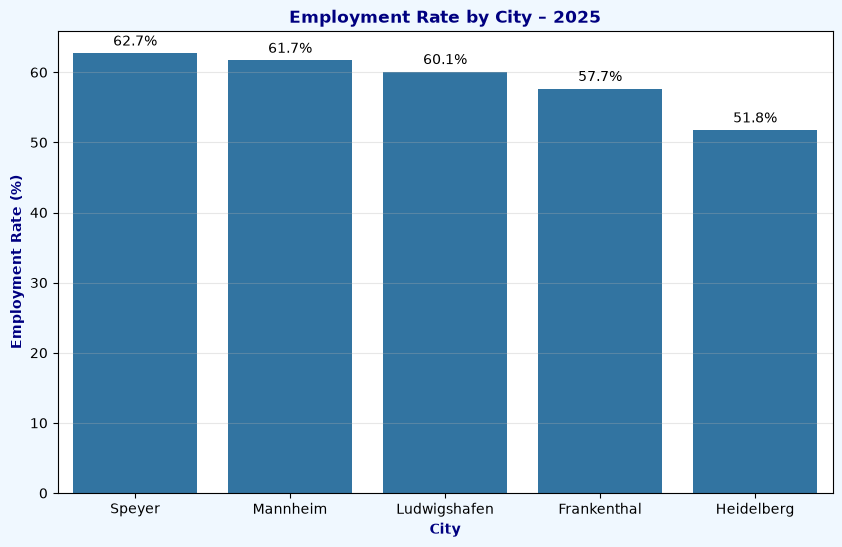

In [42]:
plt.figure(figsize=(10, 6), facecolor="aliceblue")

ax = sns.barplot(
    data=employment_rate_2025,
    x="Region",
    y="Beschäftigungsquoten_Insgesamt",
    color="steelblue"
)

ax.bar_label(
    ax.containers[0],
    fmt="%.1f%%",
    padding=3
)

sns.barplot(
    data=employment_rate_2025,
    x="Region",
    y="Beschäftigungsquoten_Insgesamt"
)

plt.title(
    "Employment Rate by City – 2025",
    fontweight="bold",
    color="navy"
)

plt.xlabel("City", fontweight="bold", color="navy")
plt.ylabel("Employment Rate (%)", fontweight="bold", color="navy")

plt.grid(axis="y", alpha=0.3)

plt.show()

### 4.2 Gender Employment Gap

Employment rates for men and women are compared to identify differences in the gender employment gap across the five cities.

In [43]:
gender_gap = employment_2025[
    [
        "Region",
        "Beschäftigungsquoten_Männer",
        "Beschäftigungsquoten_Frauen"
    ]
].copy()

gender_gap["Gender_Gap"] = (
    gender_gap["Beschäftigungsquoten_Männer"]
    - gender_gap["Beschäftigungsquoten_Frauen"]
)

gender_gap

,Region,Beschäftigungsquoten_Männer,Beschäftigungsquoten_Frauen,Gender_Gap
0,Frankenthal,62.699270,52.251819,10.447450
1,Ludwigshafen,66.022544,53.515939,12.506605
2,Speyer,65.521364,59.913271,5.608093
3,Heidelberg,54.078606,49.617991,4.460614
4,Mannheim,65.701959,57.475219,8.226740


The gender employment gap differs substantially across the five cities. Ludwigshafen shows the largest gap, with the male employment rate around 12.5 percentage points higher than the female rate. Frankenthal also records a relatively large difference, while Heidelberg has the smallest gap at approximately 4.5 percentage points.

These differences suggest that similar overall employment rates can hide important differences in labour market participation between men and women.

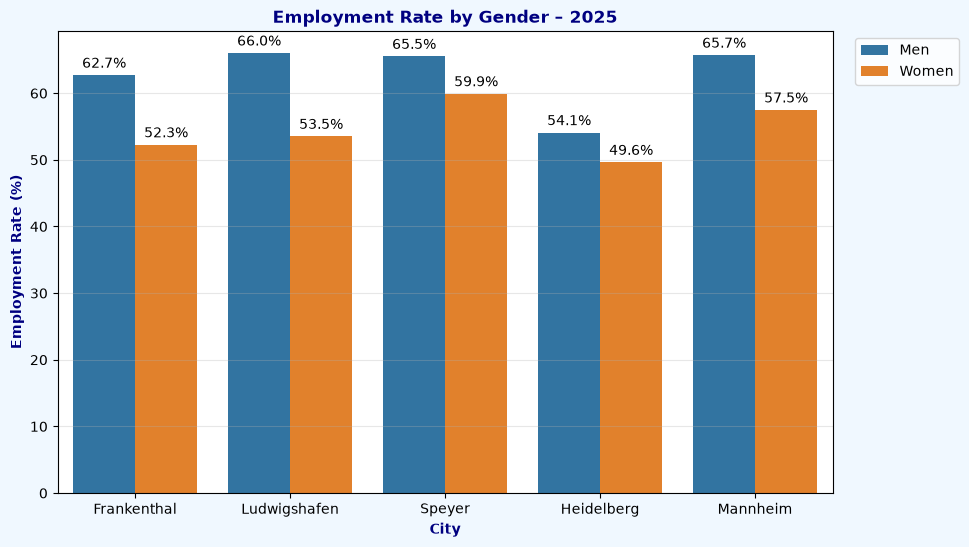

In [51]:
gender_plot = gender_gap.melt(
    id_vars="Region",
    value_vars=[
        "Beschäftigungsquoten_Männer",
        "Beschäftigungsquoten_Frauen"
    ],
    var_name="Gender",
    value_name="Employment_Rate"
)

gender_plot["Gender"] = gender_plot["Gender"].replace({
    "Beschäftigungsquoten_Männer": "Men",
    "Beschäftigungsquoten_Frauen": "Women"
})


plt.figure(figsize=(10, 6), facecolor="aliceblue")

ax = sns.barplot(
    data=gender_plot,
    x="Region",
    y="Employment_Rate",
    hue="Gender"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.title(
    "Employment Rate by Gender – 2025",
    fontweight="bold",
    color="navy"
)

plt.xlabel("City", fontweight="bold", color="navy")
plt.ylabel("Employment Rate (%)", fontweight="bold", color="navy")

plt.grid(axis="y", alpha=0.3)

plt.legend(
    title=None,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.savefig(
    "../figures/employment_rate_gender_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 4.3 Nationality Employment Gap

Employment rates for German and foreign residents are compared to examine how the employment gap by nationality varies across the five cities.

In [46]:
nationality_gap = employment_2025[
    [
        "Region",
        "Beschäftigungsquoten_Deutsche",
        "Beschäftigungsquoten_Ausländer"
    ]
].copy()

nationality_gap["Nationality_Gap"] = (
    nationality_gap["Beschäftigungsquoten_Deutsche"]
    - nationality_gap["Beschäftigungsquoten_Ausländer"]
)

nationality_gap

,Region,Beschäftigungsquoten_Deutsche,Beschäftigungsquoten_Ausländer,Nationality_Gap
0,Frankenthal,59.065774,53.854735,5.211039
1,Ludwigshafen,62.820274,55.318355,7.501919
2,Speyer,63.907761,58.259542,5.648219
3,Heidelberg,52.257587,50.354485,1.903102
4,Mannheim,65.035866,54.571852,10.464015


The nationality employment gap varies considerably across the five cities. Mannheim shows the largest difference, with the employment rate of German residents around 10.5 percentage points higher than that of foreign residents. Ludwigshafen follows with a gap of 7.5 percentage points.

Heidelberg stands out in the opposite direction, with a much smaller gap of approximately 1.9 percentage points.

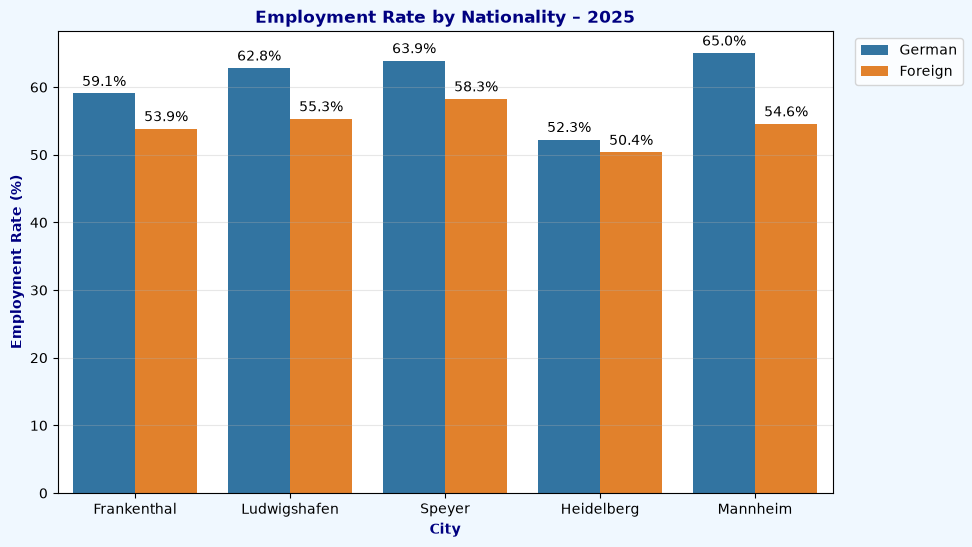

In [50]:
nationality_plot = nationality_gap.melt(
    id_vars="Region",
    value_vars=[
        "Beschäftigungsquoten_Deutsche",
        "Beschäftigungsquoten_Ausländer"
    ],
    var_name="Nationality",
    value_name="Employment_Rate"
)

nationality_plot["Nationality"] = nationality_plot["Nationality"].replace({
    "Beschäftigungsquoten_Deutsche": "German",
    "Beschäftigungsquoten_Ausländer": "Foreign"
})

nationality_plot = nationality_gap.melt(
    id_vars="Region",
    value_vars=[
        "Beschäftigungsquoten_Deutsche",
        "Beschäftigungsquoten_Ausländer"
    ],
    var_name="Nationality",
    value_name="Employment_Rate"
)

nationality_plot["Nationality"] = nationality_plot["Nationality"].replace({
    "Beschäftigungsquoten_Deutsche": "German",
    "Beschäftigungsquoten_Ausländer": "Foreign"
})


plt.figure(figsize=(10, 6), facecolor="aliceblue")

ax = sns.barplot(
    data=nationality_plot,
    x="Region",
    y="Employment_Rate",
    hue="Nationality"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.title(
    "Employment Rate by Nationality – 2025",
    fontweight="bold",
    color="navy"
)

plt.xlabel("City", fontweight="bold", color="navy")
plt.ylabel("Employment Rate (%)", fontweight="bold", color="navy")

plt.grid(axis="y", alpha=0.3)

plt.legend(
    title=None,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.savefig(
    "../figures/employment_rate_nationality_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 4.4 Employment Rate Trends (2023–2025)

Employment rates are compared across 2023, 2024 and 2025 to examine how labour market participation has evolved in each city over time.

In [52]:
employment_trend = pd.concat([
    employment_2023[["Region", "Beschäftigungsquoten_Insgesamt"]].assign(Year=2023),
    employment_2024[["Region", "Beschäftigungsquoten_Insgesamt"]].assign(Year=2024),
    employment_2025[["Region", "Beschäftigungsquoten_Insgesamt"]].assign(Year=2025)
])

employment_trend = employment_trend.rename(
    columns={"Beschäftigungsquoten_Insgesamt": "Employment_Rate"}
)

employment_trend

,Region,Employment_Rate,Year
0,Frankenthal,56.619318,2023
1,Ludwigshafen,60.928291,2023
2,Speyer,61.157516,2023
3,Heidelberg,51.065150,2023
4,Mannheim,61.676533,2023
0,Frankenthal,56.896665,2024
1,Ludwigshafen,60.371244,2024
2,Speyer,61.364558,2024
3,Heidelberg,51.346926,2024
4,Mannheim,61.703059,2024


Employment trends differ noticeably across the five cities between 2023 and 2025. Speyer records the strongest increase, rising by approximately 1.6 percentage points, while Frankenthal and Heidelberg also improve.

Mannheim remains almost unchanged, whereas Ludwigshafen is the only city in the group to record a decline, falling by approximately 0.8 percentage points.

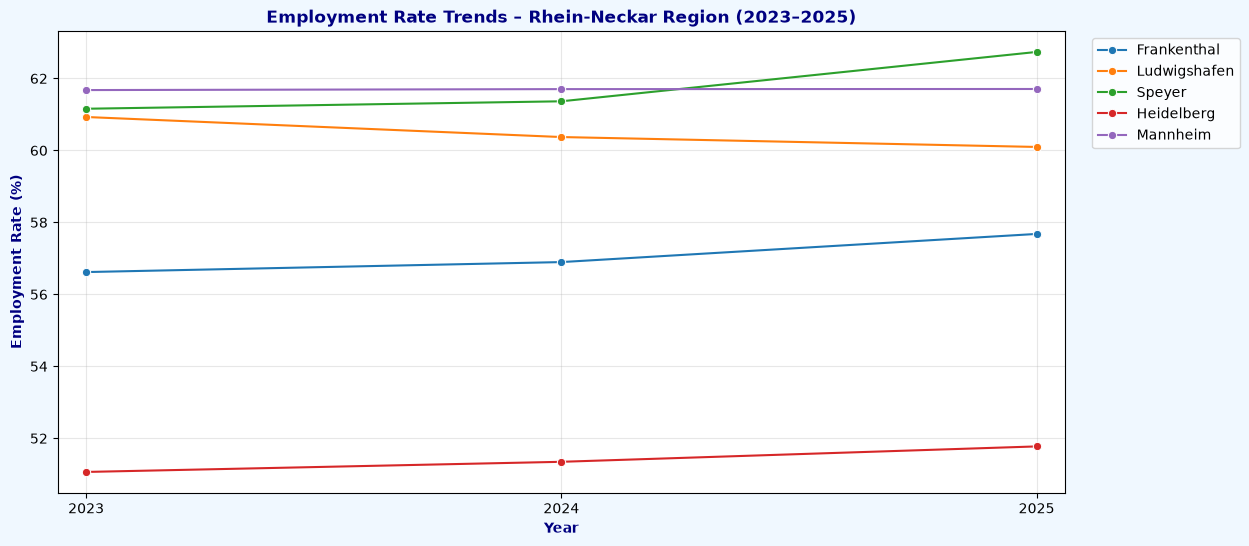

In [53]:
plt.figure(figsize=(13, 6), facecolor="aliceblue")

sns.lineplot(
    data=employment_trend,
    x="Year",
    y="Employment_Rate",
    hue="Region",
    marker="o"
)

plt.title(
    "Employment Rate Trends – Rhein-Neckar Region (2023–2025)",
    fontweight="bold",
    color="navy"
)

plt.xlabel("Year", fontweight="bold", color="navy")
plt.ylabel("Employment Rate (%)", fontweight="bold", color="navy")

plt.xticks([2023, 2024, 2025])

plt.grid(alpha=0.3)

plt.legend(
    title=None,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.margins(x=0.03)

plt.savefig(
    "../figures/employment_rate_trends_2023_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 4.5 Population Size vs Employment Rate

Population size and employment rates are compared to explore whether larger cities tend to show systematically different employment levels.

In [54]:
population_employment = employment_2025[
    [
        "Region",
        "Bevölkerung_Insgesamt",
        "Beschäftigungsquoten_Insgesamt"
    ]
].copy()

population_employment = population_employment.rename(
    columns={
        "Bevölkerung_Insgesamt": "Population",
        "Beschäftigungsquoten_Insgesamt": "Employment_Rate"
    }
)

population_employment

,Region,Population,Employment_Rate
0,Frankenthal,30311.0,57.678730
1,Ludwigshafen,118031.0,60.096076
2,Speyer,31572.0,62.735969
3,Heidelberg,112254.0,51.774547
4,Mannheim,220816.0,61.706579


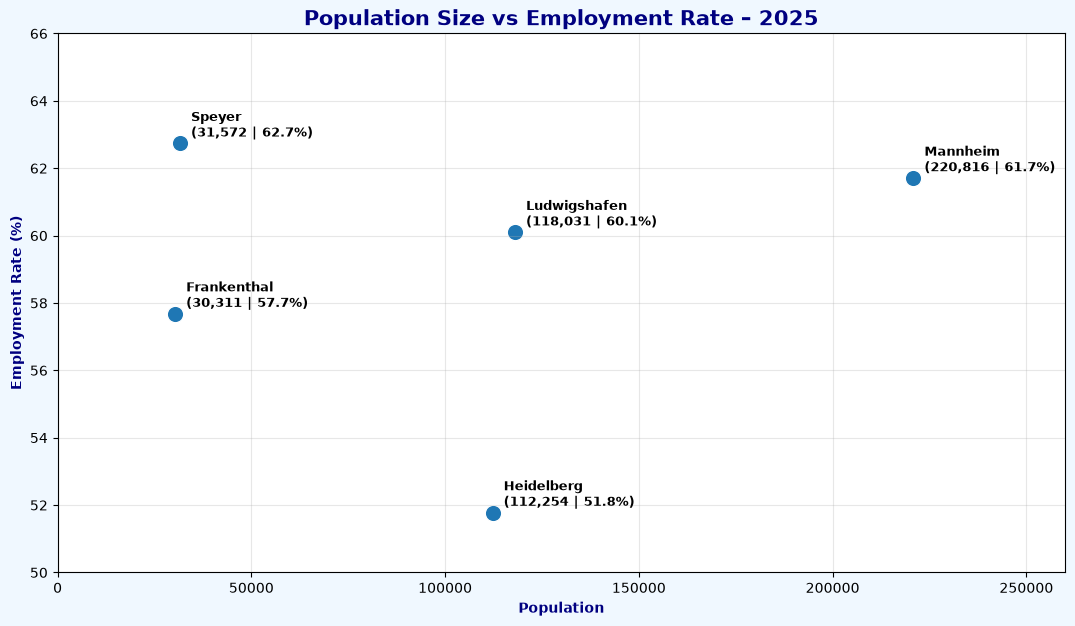

In [58]:
plt.figure(figsize=(13, 7), facecolor="aliceblue")

ax = sns.scatterplot(
    data=population_employment,
    x="Population",
    y="Employment_Rate",
    s=140
)

# Etichette delle città
for i in range(len(population_employment)):

    city = population_employment["Region"].iloc[i]
    population = population_employment["Population"].iloc[i]
    rate = population_employment["Employment_Rate"].iloc[i]

    plt.annotate(
        f"{city}\n({population:,.0f} | {rate:.1f}%)",
        (population, rate),
        xytext=(8, 5),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold"
    )

plt.title(
    "Population Size vs Employment Rate – 2025",
    fontweight="bold",
    color="navy",
    fontsize=15
)

plt.xlabel(
    "Population",
    fontweight="bold",
    color="navy"
)

plt.ylabel(
    "Employment Rate (%)",
    fontweight="bold",
    color="navy"
)

plt.xlim(0, 260000)
plt.ylim(50, 66)

plt.grid(alpha=0.3)

plt.savefig(
    "../figures/population_vs_employment_rate_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Population size does not appear to explain the differences in employment rates across the five cities.

Speyer and Frankenthal have very similar population sizes but differ by around 5 percentage points in their employment rates. A similar contrast appears between Heidelberg and Ludwigshafen, which have comparable populations but differ by more than 8 percentage points.

This suggests that factors other than city size are likely to be more relevant when explaining local employment differences.

### 4.6 Unemployment Trends (2023–2025)

Monthly unemployment rates are analysed to compare how unemployment has evolved across the five cities and to identify recurring patterns over time.

In [60]:
unemployment_long["Month"] = unemployment_long["Date"].dt.month
unemployment_long["Year"] = unemployment_long["Date"].dt.year

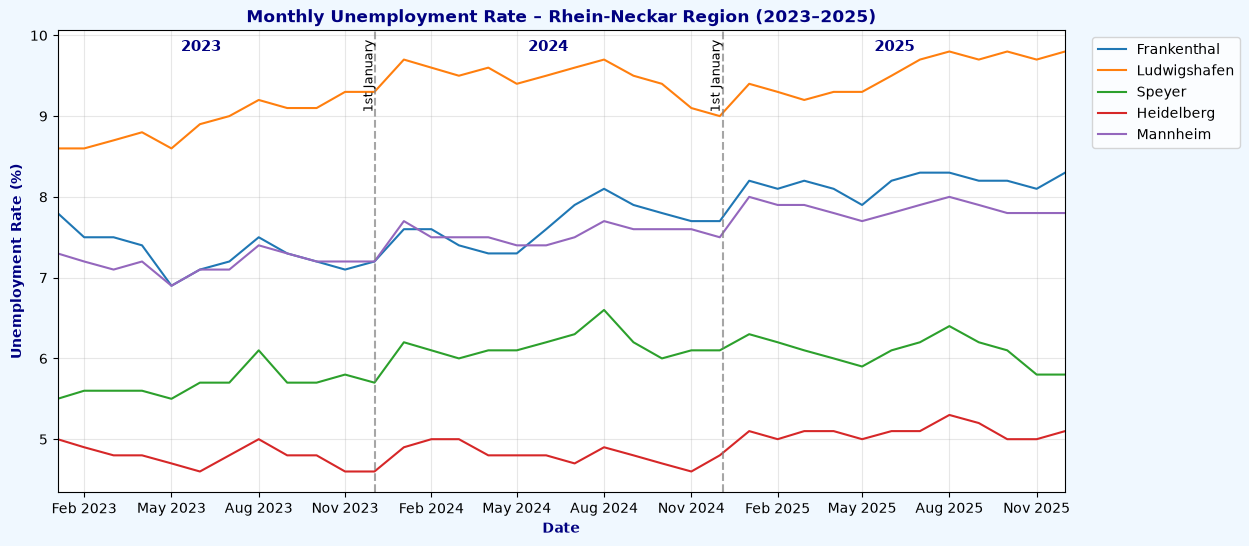

In [64]:
import matplotlib.dates as mdates

plt.figure(figsize=(13, 6), facecolor="aliceblue")

sns.lineplot(
    data=unemployment_long,
    x="Date",
    y="Unemployment_Rate",
    hue="Region"
)

plt.title(
    "Monthly Unemployment Rate – Rhein-Neckar Region (2023–2025)",
    fontweight="bold",
    color="navy"
)

plt.xlabel("Date", fontweight="bold", color="navy")
plt.ylabel("Unemployment Rate (%)", fontweight="bold", color="navy")

plt.grid(alpha=0.3)

# Legenda fuori dal grafico
plt.legend(
    title=None,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

# Date reali del dataset sull'asse X
tick_dates = unemployment_long[
    unemployment_long["Month"].isin([2, 5, 8, 11])
]["Date"].unique()

plt.xticks(tick_dates)

plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

# Linee verticali tra gli anni
plt.axvline(
    pd.Timestamp("2024-01-01"),
    color="gray",
    linestyle="--",
    alpha=0.7
)

plt.axvline(
    pd.Timestamp("2025-01-01"),
    color="gray",
    linestyle="--",
    alpha=0.7
)

# Scritta sulle linee
plt.text(
    pd.Timestamp("2024-01-01"),
    9.95,
    "1st January",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9
)

plt.text(
    pd.Timestamp("2025-01-01"),
    9.95,
    "1st January",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9
)

# Anni centrati nei rispettivi spazi
plt.text(
    pd.Timestamp("2023-07-01"),
    9.95,
    "2023",
    ha="center",
    va="top",
    fontsize=11,
    fontweight="bold",
    color="navy"
)

plt.text(
    pd.Timestamp("2024-07-01"),
    9.95,
    "2024",
    ha="center",
    va="top",
    fontsize=11,
    fontweight="bold",
    color="navy"
)

plt.text(
    pd.Timestamp("2025-07-01"),
    9.95,
    "2025",
    ha="center",
    va="top",
    fontsize=11,
    fontweight="bold",
    color="navy"
)

plt.margins(x=0)

plt.savefig(
    "../figures/monthly_unemployment_rate_2023_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Final Observations

Looking at the labour market of these five cities over the 2023–2025 period, what stands out to me most is how different their profiles are despite being geographically close to each other.

Ludwigshafen consistently shows relatively high employment rates, but at the same time it also records the highest unemployment levels among the five cities. Heidelberg presents almost the opposite picture, with the lowest employment rate but also the lowest unemployment rate.

The analysis also revealed differences within the employed population. Gender and nationality employment gaps vary considerably from one city to another, showing that a single overall employment rate does not tell the whole story.

Over the three years, most cities show relatively small changes in employment rates, while the monthly unemployment data reveals more visible fluctuations and some recurring seasonal patterns.

One of the main things I take away from this analysis is that cities located within the same regional area can have very different labour market profiles.

For me, this was also a useful reminder of why looking at several indicators together is more informative than relying on a single number.